In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl


from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from data_generation.differential_equations import PoissonSetup1LeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function
from utils import evaluate_expression


from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, print_model_size
from typing import Optional
import pickle
from tqdm import tqdm
import einops
from models import ResNet1d, MLP

----------------------------------------
2025-12-12 16:00:38 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"
model_train_outputs_path = repo_path + "/results/poisson_setup1/model_train_outputs/pcanet"
model_test_outputs_path = repo_path + "/results/poisson_setup1/model_test_outputs/pcanet"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)

In [3]:
p_dof = load_npy(train_dataset_path+'/p_dof.npy')
p_vertex_values = load_npy(train_dataset_path+'/p_vertex_values.npy')
sigma_u_dof = load_npy(train_dataset_path+'/sigma_u_dof.npy')
sigma_vertex_values = load_npy(train_dataset_path+'/sigma_vertex_values.npy')
u_vertex_values = load_npy(train_dataset_path+'/u_vertex_values.npy')

In [4]:
print("p_dof shape: ", p_dof.shape)
print("p_vertex_values shape: ", p_vertex_values.shape)
print("sigma_u_dof shape: ", sigma_u_dof.shape)
print("sigma_vertex_values shape: ", sigma_vertex_values.shape)
print("u_vertex_values shape: ", u_vertex_values.shape)

p_dof shape:  (5000, 32768)
p_vertex_values shape:  (5000, 16641)
sigma_u_dof shape:  (5000, 230401)
sigma_vertex_values shape:  (5000, 16641, 2)
u_vertex_values shape:  (5000, 16641, 1)


In [5]:
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [6]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [7]:
# num_k_fc = len(k_dof)
# num_sigma_u_fc = len(sigma_u_dof)

# k_vertex_values = np.zeros((num_k_fc, num_vertices))
# u_vertex_values = np.zeros((num_sigma_u_fc, num_vertices, 1))
# sigma_vertex_values = np.zeros((num_sigma_u_fc, num_vertices, 2))

# image_k_vertex_values = np.zeros((num_k_fc, mesh_args['num_y']+1, mesh_args['num_x']+1))
# image_u_vertex_values = np.zeros((num_sigma_u_fc, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
# image_sigma_vertex_values = np.zeros((num_sigma_u_fc, 2, mesh_args['num_y']+1, mesh_args['num_x']+1))

# dolfinx_mesh_coords = mesh.geometry.x[:,:2]
# num_vertices = len(dolfinx_mesh_coords)
# num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
# x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
# y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
# image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
# perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

# CG_element = basix.ufl.element('CG', 'triangle', 1)
# Vh['CG1'] = dolfinx.fem.functionspace(mesh, CG_element)

In [8]:
# for i in tqdm(range(num_k_fc), desc="Evaluating k on grid points"):
#     k = dolfinx.fem.Function(Vh['CG1'])
#     k.x.array[:] = k_dof[i]
#     k_vertex_values[i][perm] = k.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])]
#     image_k_vertex_values[i] = k_vertex_values[i].reshape(num_x+1, num_y+1).T

In [9]:
num_p_fc = len(p_dof)
num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
image_p_vertex_values = np.zeros((num_p_fc, num_y+1, num_x+1))
for i in tqdm(range(num_p_fc)):
    image_p_vertex_values[i,:,:] = p_vertex_values[i].reshape(num_x+1, num_y+1).T

100%|██████████| 5000/5000 [00:00<00:00, 5031.13it/s]


In [10]:
# num_sigma_fc = len(sigma_vertex_values)
# image_sigma_vertex_values = np.zeros((num_sigma_fc, 2, mesh_args['num_y']+1, mesh_args['num_x']+1))
# for i in tqdm(range(num_sigma_fc)):
#     image_sigma_vertex_values[i, 0, :, :] = sigma_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T
#     image_sigma_vertex_values[i, 1, :, :] = sigma_vertex_values[i, :, 1].reshape(num_x+1, num_y+1).T

# num_u_fc = len(u_vertex_values)
# image_u_vertex_values = np.zeros((num_u_fc, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
# for i in tqdm(range(num_u_fc)):
#     image_u_vertex_values[i, 0, :, :] = u_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T

In [11]:
# for i in tqdm(range(num_sigma_u_fc), desc="Evaluating sigma_u on grid points"):
#     sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
#     sigma_u_fc.x.array[:] = sigma_u_dof[i]
#     sigma_fc = sigma_u_fc.sub(0).collapse()
#     u_fc = sigma_u_fc.sub(1).collapse()

#     sigma_grid_evals = evaluate_expression(mesh, sigma_fc, mesh.geometry.x)[1]
#     u_grid_evals = evaluate_expression(mesh, u_fc, mesh.geometry.x)[1]

#     sigma_vertex_values[i, perm, 0] = sigma_grid_evals[:, 0]
#     sigma_vertex_values[i, perm, 1] = sigma_grid_evals[:, 1]
#     u_vertex_values[i, perm, 0] = u_grid_evals[:, 0]
 
#     image_sigma_vertex_values[i, 0, :, :] = sigma_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T
#     image_sigma_vertex_values[i, 1, :, :] = sigma_vertex_values[i, :, 1].reshape(num_x+1, num_y+1).T
#     image_u_vertex_values[i, 0, :, :] = u_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T

# np.save(train_dataset_path+'/image_k_vertex_values.npy', image_k_vertex_values)
# np.save(train_dataset_path+'/image_u_vertex_values.npy', image_u_vertex_values)
# np.save(train_dataset_path+'/image_sigma_vertex_values.npy', image_sigma_vertex_values)

In [12]:
# image_k_vertex_values = load_npy(train_dataset_path+'/image_k_vertex_values.npy')
# image_u_vertex_values = load_npy(train_dataset_path+'/image_u_vertex_values.npy')
# image_sigma_vertex_values = load_npy(train_dataset_path+'/image_sigma_vertex_values.npy')

In [13]:
num_sigma_u_fc = len(sigma_u_dof)
image_u_vertex_values = np.zeros((num_sigma_u_fc, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
image_sigma_vertex_values = np.zeros((num_sigma_u_fc, 2, mesh_args['num_y']+1, mesh_args['num_x']+1))
for i in tqdm(range(num_sigma_u_fc)):
    image_sigma_vertex_values[i, 0, :, :] = sigma_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T
    image_sigma_vertex_values[i, 1, :, :] = sigma_vertex_values[i, :, 1].reshape(num_x+1, num_y+1).T
    image_u_vertex_values[i, 0, :, :] = u_vertex_values[i, :, 0].reshape(num_x+1, num_y+1).T

100%|██████████| 5000/5000 [00:02<00:00, 1978.41it/s]


In [14]:
# image_k_vertex_values = load_npy(train_dataset_path+'/image_k_vertex_values.npy').reshape(num_k_fc, mesh_args['num_x']+1, mesh_args['num_y']+1).transpose(0, 2, 1)
# image_u_vertex_values = load_npy(train_dataset_path+'/image_u_vertex_values.npy').reshape(num_sigma_u_fc, mesh_args['num_x']+1, mesh_args['num_y']+1, 1).transpose(0, 2, 1, 3)
# image_sigma_vertex_values = load_npy(train_dataset_path+'/image_sigma_vertex_values.npy').reshape(num_sigma_u_fc, mesh_args['num_x']+1, mesh_args['num_y']+1, 2).transpose(0, 2, 1, 3)

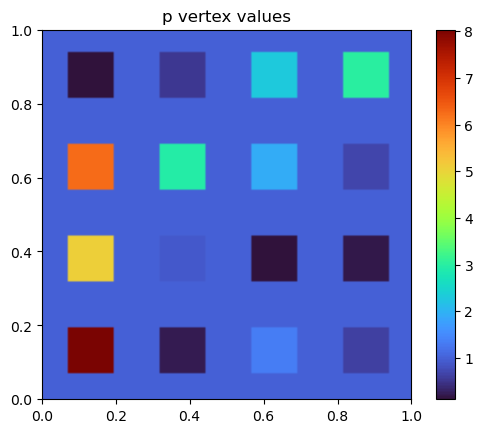

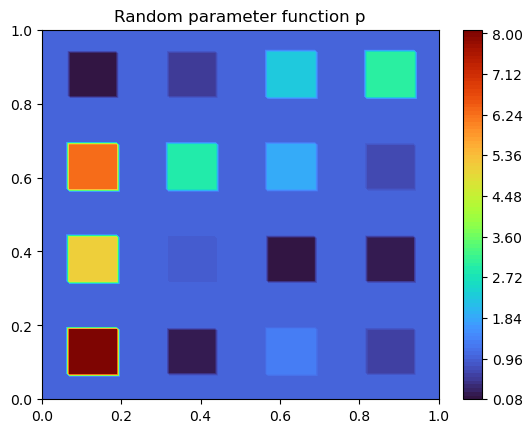

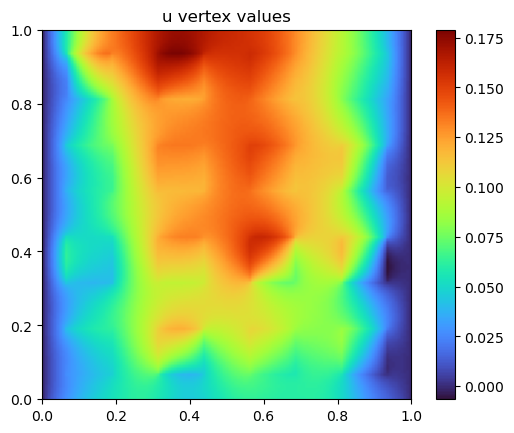

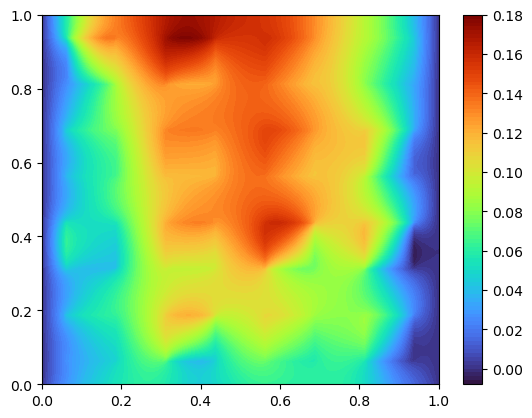

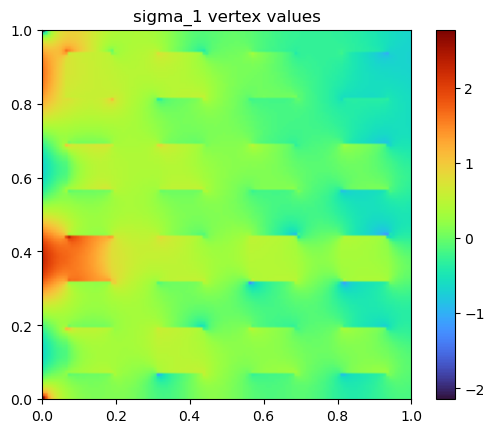

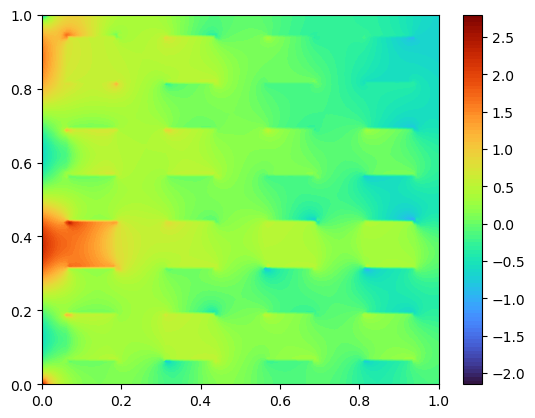

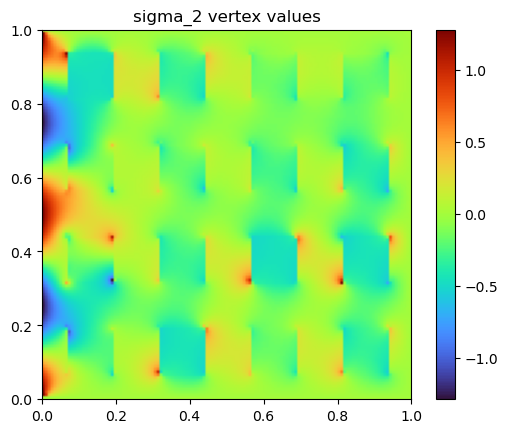

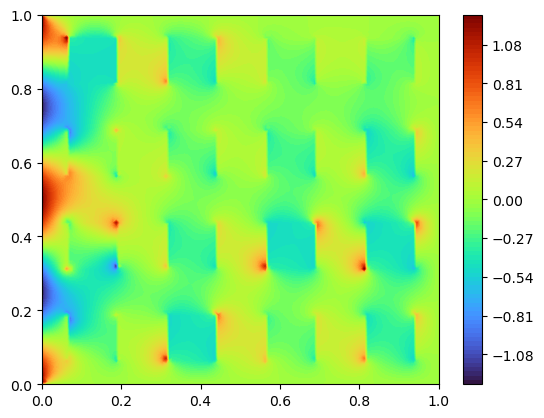

In [15]:
sample_index = 1000
plt.imshow(image_p_vertex_values[sample_index], extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower', cmap='turbo')
plt.title("p vertex values")
plt.colorbar()
plt.show()

x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]
p = dolfinx.fem.Function(Vh['p'])
p.x.array[:] = p_dof[sample_index]
plt.tricontourf(x, y, evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.title('Random parameter function p')
plt.show()



sigma_u = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u.x.array[:] = sigma_u_dof[sample_index]
sigma = sigma_u.sub(0).collapse()
u = sigma_u.sub(1).collapse()


plt.imshow(image_u_vertex_values[sample_index, 0, :, :], extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower', cmap='turbo')
plt.title("u vertex values")
plt.colorbar()
plt.show()

plt.tricontourf(x, y, evaluate_expression(mesh, u, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.show()


plt.imshow(image_sigma_vertex_values[sample_index, 0, :, :], extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower', cmap='turbo')
plt.title("sigma_1 vertex values")
plt.colorbar()
plt.show()  

plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.show()

plt.imshow(image_sigma_vertex_values[sample_index, 1, :, :], extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower', cmap='turbo')
plt.title("sigma_2 vertex values")
plt.colorbar()
plt.show()

plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 1], cmap='turbo', levels=100)
plt.colorbar()
plt.show()

In [16]:
# pod_basis_dof = np.load(train_dataset_path+'/pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
# pod_coeff_labels = np.load(train_dataset_path+'/pod_coeff_labels.npy')[:,:output_reduced_basis_args['num_basis']]

In [17]:
# quadratic_weight = torch.tensor(np.load(train_dataset_path+'/quadratic_weight.npy'), dtype=torch_dtype['float64'])
# linear_weight = torch.tensor(np.load(train_dataset_path+'/linear_weight.npy'), dtype=torch_dtype['float64'])
# bias = torch.tensor(np.load(train_dataset_path+'/bias.npy'), dtype=torch_dtype['float64'])

In [18]:
device = torch.device('cuda:1')

In [19]:
def compute_pod_basis(snapshot: np.ndarray, num_basis: int, weight: np.ndarray = None) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute POD basis using NumPy.

    Parameters:
        snapshot: (num_samples, num_dof) complex or real ndarray
        num_basis: number of POD modes to extract
        weight: (num_dof, num_dof) ndarray, optional

    Returns:
        sqrt_eigvals: (num_basis,) ndarray of sqrt of top eigenvalues
        pod_basis: (num_dof, num_basis) ndarray of POD modes
    """
    num_samples, num_dof = snapshot.shape
    assert num_basis < num_dof

    if weight is None:
        C = snapshot @ snapshot.T
    else:
        C = snapshot @ weight @ snapshot.T

    eigvals, eigvecs = np.linalg.eigh(C)  # ascending order
    eigvals = eigvals[-num_basis:]
    eigvecs = eigvecs[:, -num_basis:]


    # Sort eigenvalues and eigenvectors in descending order
    # Note that np.flip is not in-place, need to mannually copy to accelerate the following computation
    eigvals = np.flip(eigvals, axis=0).copy() 
    eigvecs = np.flip(eigvecs, axis=1).copy()

    temp = snapshot.T @ eigvecs
    pod_basis = np.zeros((num_dof, num_basis), dtype=snapshot.dtype)
    for i in range(num_basis):
        pod_basis[:, i] = temp[:, i] / np.sqrt(eigvals[i])

    return np.sqrt(eigvals), pod_basis

In [20]:
num_samples_for_constructing_pod_basis = output_reduced_basis_args['num_evals']
num_input_basis = 20
num_output_basis = 128 

p_eigvals, p_pod_basis = compute_pod_basis(einops.rearrange(image_p_vertex_values[:num_samples_for_constructing_pod_basis], 'b h w -> b (h w)'), num_basis=num_input_basis)
image_sigma_u_vertex_values = np.concatenate((image_sigma_vertex_values, image_u_vertex_values), axis=1)

sigma_eigvals, sigma_pod_basis = compute_pod_basis(einops.rearrange(image_sigma_vertex_values[:num_samples_for_constructing_pod_basis], 'b c h w -> b (c h w)'), num_basis=num_output_basis)
u_eigvals, u_pod_basis = compute_pod_basis(einops.rearrange(image_u_vertex_values[:num_samples_for_constructing_pod_basis], 'b c h w -> b (c h w)'), num_basis=num_output_basis)
sigma_u_eigvals, sigma_u_pod_basis = compute_pod_basis(einops.rearrange(image_sigma_u_vertex_values[:num_samples_for_constructing_pod_basis], 'b c h w -> b (c h w)'), num_basis=num_output_basis)

In [21]:
reduced_p = einops.rearrange(image_p_vertex_values, 'b h w -> b (h w)') @ p_pod_basis
reduced_sigma = einops.rearrange(image_sigma_vertex_values, 'b c h w -> b (c h w)') @ sigma_pod_basis
reduced_u = einops.rearrange(image_u_vertex_values, 'b c h w -> b (c h w)') @ u_pod_basis
reduced_sigma_u = einops.rearrange(image_sigma_u_vertex_values, 'b c h w -> b (c h w)') @ sigma_u_pod_basis

In [23]:
# reconstructed_sigma_u = einops.rearrange(reduced_sigma_u @ sigma_u_pod_basis.T, 'b (c h w) -> b c h w', c=3, h=129, w=129)

# temp= 0 
# for i in range(10):
#     temp += np.sum((reconstructed_sigma_u[i] - image_sigma_u_vertex_values[i])**2)**(1/2) / np.sum(image_sigma_u_vertex_values[i]**2)**(1/2)
# temp /= 10

# print(temp)

In [24]:
# reconstructed_p = einops.rearrange(reduced_p @ p_pod_basis.T, 'b (h w) -> b h w', h=129, w=129)

# temp= 0 
# for i in range(10):
#     temp += np.sum((reconstructed_p[i] - image_p_vertex_values[i])**2)**(1/2) / np.sum(image_p_vertex_values[i]**2)**(1/2)
# temp /= 10

# print(temp)

In [25]:
reduced_p_tensor = torch.tensor(reduced_p, dtype=torch_dtype['float32'])
reduced_u_tensor = torch.tensor(reduced_u, dtype=torch_dtype['float32'])
reduced_sigma_tensor = torch.tensor(reduced_sigma, dtype=torch_dtype['float32'])
reduced_sigma_u_tensor = torch.tensor(reduced_sigma_u, dtype=torch_dtype['float32'])
print(f'reduced_p_tensor shape: {reduced_p_tensor.shape}')
print(f'reduced_u_tensor shape: {reduced_u_tensor.shape}')
print(f'reduced_sigma_tensor shape: {reduced_sigma_tensor.shape}')
print(f'reduced_sigma_u_tensor shape: {reduced_sigma_u_tensor.shape}')

reduced_p_tensor shape: torch.Size([5000, 20])
reduced_u_tensor shape: torch.Size([5000, 128])
reduced_sigma_tensor shape: torch.Size([5000, 128])
reduced_sigma_u_tensor shape: torch.Size([5000, 128])


In [26]:
# image_k_vertex_values_tensor = torch.tensor(image_k_vertex_values, dtype=torch_dtype['float32'])
# image_u_vertex_values_tensor = torch.tensor(image_u_vertex_values, dtype=torch_dtype['float32'])
# image_sigma_vertex_values_tensor = torch.tensor(image_sigma_vertex_values, dtype=torch_dtype['float32'])
# image_sigma_u_vertex_values_tensor = torch.cat((image_sigma_vertex_values_tensor, image_u_vertex_values_tensor), dim=1)
# image_sigma_u_vertex_values_tensor = image_sigma_u_vertex_values_tensor.permute(0, 3, 1, 2)

In [27]:
# image_k_vertex_values_tensor = torch.tensor(image_k_vertex_values, dtype=torch_dtype['float32'])
# image_u_vertex_values_tensor = torch.tensor(image_u_vertex_values, dtype=torch_dtype['float32'])
# image_sigma_vertex_values_tensor = torch.tensor(image_sigma_vertex_values, dtype=torch_dtype['float32'])
# image_sigma_u_vertex_values_tensor = torch.cat((image_sigma_vertex_values_tensor, image_u_vertex_values_tensor), dim=-1)
# image_sigma_u_vertex_values_tensor = image_sigma_u_vertex_values_tensor.permute(0, 3, 1, 2)

In [28]:
# from neuralop.models import FNO

In [29]:
# class ModifiedFNO(nn.Module):
#     def __init__(self, num_basis):
#         super().__init__()
#         self.num_basis = num_basis
#         self.FNO = FNO(
#             n_modes=(32, 32), 
#             hidden_channels=128, 
#             in_channels=1, 
#             out_channels=1,
#             n_layers=4,
#         )
#         self.linear = nn.Linear(81*81, self.num_basis)
#         self.loss_record = None

#     def forward(self, p):
#         y = self.FNO(p)
#         y = y.view(-1, 81*81)
#         y = self.linear(y)
#         return y

In [30]:
class BatchIndicesIterator:
    def __init__(self, start: int, end: int, batch_size: int, shuffle: bool=True):
        self.start = start
        self.end = end
        if  self.start >= self.end:
            raise ValueError(f'The start index {self.start} must be less than the end index {self.end}.')
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = torch.arange(start, end)
        self.num_indices = len(self.indices)
        self.current_index = 0

        if self.shuffle:
            self.indices = self.indices[torch.randperm(self.num_indices)]

    def __iter__(self):
        return self

    def __next__(self):
        if self.current_index >= self.end - self.start:
            if self.shuffle:
                self.indices = self.indices[torch.randperm(self.num_indices)]
            self.current_index = 0
            raise StopIteration

        batch_indices = self.indices[self.current_index:self.current_index + self.batch_size]
        self.current_index += self.batch_size
        return batch_indices

In [31]:
def pretty_print_loss(loss_dict):
    formatted_loss = {key: value.item() for key, value in loss_dict.items()}
    print(', '.join(f"'{key}': {value}" for key, value in formatted_loss.items()))

In [32]:
class RelativeL2Loss(nn.Module):
    def __init__(self, eps=1e-10, reduction='sum'):
        super().__init__()
        self.eps = eps
        self.reduction = reduction

    def l2_norm(self, x):
        if x.dim() == 2:
            return torch.sum(x**2, dim=1)**(1/2)
        elif x.dim() == 3:
            return torch.sum(x**2, dim=(1,2))**(1/2)
        elif x.dim() == 4:
            return torch.sum(x**2, dim=(1,2,3))**(1/2)
        else:
            raise ValueError('Unsupported tensor shape')

    def forward(self, outputs, labels):
        diff = outputs - labels
        loss = self.l2_norm(diff) / (self.l2_norm(labels) + self.eps)
        if self.reduction == 'sum':
            return torch.sum(loss, dim=0)
        else:
            return torch.mean(loss, dim=0)

In [33]:
# class AddSpatialCoordinates(nn.Module):
#     def __init__(self, num_x: int, num_y: int): 
#         super().__init__()
#         self.num_x, self.num_y = (num_x, num_y)
#         self.x = np.linspace(0, 1, num_x)
#         self.y = np.linspace(0, 1, num_y)
#         self.x_coor, self.y_coor = np.meshgrid(self.x, self.y)
#         self.x_coor = torch.from_numpy(self.x_coor).to(dtype=torch.float32)
#         self.y_coor = torch.from_numpy(self.y_coor).to(dtype=torch.float32)

#     def forward(self, inputs):
#         repeat_x_coor = self.x_coor.repeat(inputs.shape[0],1,1)
#         repeat_y_coor = self.y_coor.repeat(inputs.shape[0],1,1)
#         outputs = torch.stack((inputs, repeat_x_coor, repeat_y_coor), dim=1)
#         return outputs

#     def to(self, device):
#         self.x_coor = self.x_coor.to(device)
#         self.y_coor = self.y_coor.to(device)
#         return self

In [34]:
# add_spatial_coordinates = AddSpatialCoordinates(num_x+1, num_y+1)
# add_spatial_coordinates = add_spatial_coordinates.to(device)

In [35]:
# model = FNO(
#     n_modes=(32, 32), 
#     hidden_channels=128, 
#     in_channels=3, 
#     out_channels=3,
#     n_layers=4,
# )

# model = model.to(device)

In [37]:
# model = ResNet1d(
#     input_dim=num_input_basis,
#     output_dim=num_output_basis,
#     hidden_dim=num_output_basis,
#     hidden_depth=5,
#     activation="relu",
#     init_func="kaiming_normal"
# )

model = MLP(
    input_dim=num_input_basis,
    output_dim=num_output_basis
)

_, _ = print_model_size(model)
model = model.to(device)

Total number of model parameters: 4350080 (~16.59 MiB)


In [38]:
relative_l2_loss = RelativeL2Loss(reduction='mean')
l2_loss = nn.MSELoss(reduction='mean')

In [39]:
iterations = 3000
num_train = output_reduced_basis_args['num_evals']
num_valid = 500

batch_size = {
    'train': num_train,
    'valid': num_valid
}

In [40]:
print(f'num_train: {num_train}')

num_train: 500


In [41]:
input_scaler_statistics = {
    'mean': reduced_p_tensor[:num_train].mean(dim=0).to(device),
    'std': reduced_p_tensor[:num_train].std(dim=0).to(device)
}
output_scaler_statistics = {
    'mean': reduced_sigma_u_tensor[:num_train].mean(dim=0).to(device),
    'std': reduced_sigma_u_tensor[:num_train].std(dim=0).to(device)
}

In [42]:
loss_history = {
    'train': [],
    'valid': []
}
valid_start_index = 4500

train_batch_indices_iterator = BatchIndicesIterator(start=0, end=num_train, batch_size=batch_size['train'], shuffle=True)
valid_batch_indices_iterator = BatchIndicesIterator(start=valid_start_index, end=valid_start_index + num_valid, batch_size=batch_size['valid'], shuffle=False)

print(f'num_training_samples: {num_train}')
# optimizer = SOAP(params=model.parameters(), lr = 5e-3, betas=(.95, .95), weight_decay=.01, precondition_frequency=5)  
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)  
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.9)

best_val_loss = float('inf')
best_model_path = os.path.join(model_train_outputs_path, f"best_model_params_{num_train}.pth")
best_model_iterations = []  

counter = 0 
while counter < iterations:
    for batch_indices in train_batch_indices_iterator:
        input_ = reduced_p_tensor[batch_indices].to(device)
        input_ = (input_ - input_scaler_statistics['mean']) / input_scaler_statistics['std']
        output = model(input_) 
        # label_sigma = reduced_sigma_tensor[batch_indices].to(device)
        # label_u = reduced_u_tensor[batch_indices].to(device)
        label = reduced_sigma_u_tensor[batch_indices].to(device)
        label = (label - output_scaler_statistics['mean']) / output_scaler_statistics['std']
        # loss = relative_l2_loss(output, label) 
        loss = l2_loss(output, label)
        # loss = l2_loss(output[:, :num_output_basis], label_sigma) + l2_loss(output[:, num_output_basis:], label_u)
        loss /= len(batch_indices)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        counter += 1
        print('')
        print(f'Iteration: {counter}')
        print(f'Train loss: {loss.item()}')
        loss_history['train'].append(loss.item())

        with torch.no_grad():
            model.eval()
            valid_loss = 0.0
            for valid_batch_indices in valid_batch_indices_iterator:
                valid_input = reduced_p_tensor[valid_batch_indices].to(device)
                valid_input = (valid_input - input_scaler_statistics['mean']) / input_scaler_statistics['std']
                valid_output = model(valid_input)
                # valid_label_sigma = reduced_sigma_tensor[valid_batch_indices].to(device)
                # valid_label_u = reduced_u_tensor[valid_batch_indices].to(device)
                valid_label = reduced_sigma_u_tensor[valid_batch_indices].to(device)
                valid_label = (valid_label - output_scaler_statistics['mean']) / output_scaler_statistics['std']
                # valid_loss += (relative_l2_loss(valid_output, valid_label).item())
                valid_loss = l2_loss(valid_output, valid_label).item()
                # valid_loss += (l2_loss(valid_output[:, :num_output_basis], valid_label_sigma) + l2_loss(valid_output[:, num_output_basis:], valid_label_u)).item()
            valid_loss /= num_valid
            loss_history['valid'].append(valid_loss)
            print(f'Valid loss: {valid_loss}')
            if valid_loss < best_val_loss:
                best_val_loss = valid_loss
                torch.save(model.state_dict(), best_model_path)
                best_model_iterations.append(counter)
                print(f"New best model saved at iteration {counter} with validation loss {best_val_loss:.6f}")

    lr_scheduler.step()

# Save training history and final model
loss_history = {key: np.array(value) for key, value in loss_history.items()}
np.save(os.path.join(model_train_outputs_path, f'loss_history_{num_train}.npy'), loss_history)
torch.save(model.state_dict(), os.path.join(model_train_outputs_path, f"latest_model_params_{num_train}.pth"))

num_training_samples: 500

Iteration: 1
Train loss: 0.002065537730231881
Valid loss: 0.0028072247505187987
New best model saved at iteration 1 with validation loss 0.002807

Iteration: 2
Train loss: 0.0021026867907494307
Valid loss: 0.0026319851875305175
New best model saved at iteration 2 with validation loss 0.002632

Iteration: 3
Train loss: 0.0019180778181180358
Valid loss: 0.00255161190032959
New best model saved at iteration 3 with validation loss 0.002552

Iteration: 4
Train loss: 0.001833015470765531
Valid loss: 0.0025305132865905762
New best model saved at iteration 4 with validation loss 0.002531

Iteration: 5
Train loss: 0.0018121447646990418
Valid loss: 0.002493764638900757
New best model saved at iteration 5 with validation loss 0.002494

Iteration: 6
Train loss: 0.0017724178032949567
Valid loss: 0.00248305344581604
New best model saved at iteration 6 with validation loss 0.002483

Iteration: 7
Train loss: 0.0017570856725797057
Valid loss: 0.0024921352863311766

Iteration:

In [43]:
# model = ResNet1d(
#     input_dim=num_input_basis,
#     output_dim=num_output_basis,
#     hidden_dim=num_output_basis,
#     hidden_depth=5,
#     activation="relu",
#     init_func="kaiming_normal"
# )

model = MLP(
    input_dim=num_input_basis,
    output_dim=num_output_basis
)

state_dict = torch.load(os.path.join(model_train_outputs_path, f"best_model_params_{num_train}.pth"), weights_only=False)
model.load_state_dict(state_dict)
model = model.to(device)

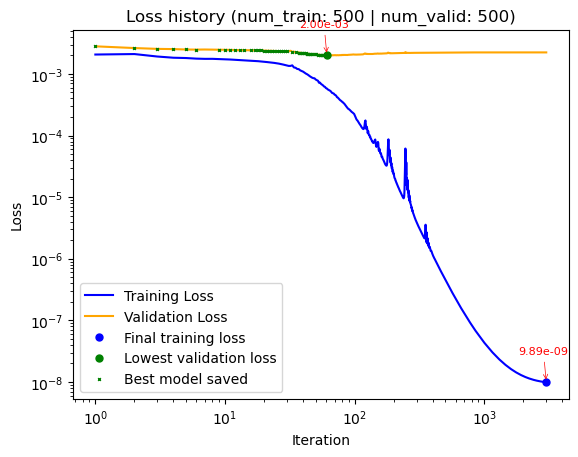

In [44]:
counter_indices = np.arange(1, len(loss_history['train'])+1)
plt.loglog(counter_indices, loss_history['train'], label='Training Loss', color='blue')
plt.loglog(counter_indices, loss_history['valid'], label='Validation Loss', color='orange')
plt.plot(counter_indices[-1], loss_history['train'][-1], 'bo', markersize=5, label='Final training loss')  # blue dot on last point
plt.plot(best_model_iterations[-1], loss_history['valid'][best_model_iterations[-1]-1], 'go', markersize=5, label='Lowest validation loss')  # red dot for best model iteration
plt.plot(best_model_iterations, [loss_history['valid'][i-1] for i in best_model_iterations], 'gx', markersize=2, label='Best model saved')  # green dots for best model iterations
# Annotate the last value
plt.annotate(f'{loss_history['train'][-1]:.2e}',
             xy=(counter_indices[-1], loss_history['train'][-1]),
             xytext=(-20, 20),
             textcoords='offset points',
             color='red',
             fontsize=8,
             arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

plt.annotate(f'{loss_history['valid'][best_model_iterations[-1]-1]:.2e}',
                xy=(best_model_iterations[-1], loss_history['valid'][best_model_iterations[-1]-1]),
                xytext=(-20, 20),
                textcoords='offset points',
                color='red',
                fontsize=8,
                arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Loss history (num_train: {num_train} | num_valid: {num_valid})')
plt.legend()
plt.savefig(os.path.join(model_train_outputs_path, f'loss_history_{num_train}.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [45]:
num_test = 500

test_p_dof = load_npy(test_dataset_path+'/p_dof.npy')[:num_test]
test_p_vertex_values = load_npy(test_dataset_path+'/p_vertex_values.npy')[:num_test]
test_sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')[:num_test]
test_sigma_vertex_values = load_npy(test_dataset_path+'/sigma_vertex_values.npy')[:num_test]
test_u_vertex_values = load_npy(test_dataset_path+'/u_vertex_values.npy')[:num_test]
test_sigma_u_dof = torch.tensor(test_sigma_u_dof)

In [46]:
# test_k_vertex_values = np.zeros((num_test, num_vertices))
# test_image_k_vertex_values = np.zeros((num_test, mesh_args['num_y']+1, mesh_args['num_x']+1))
# for i in range(num_test):
#     k = dolfinx.fem.Function(Vh['CG1'])
#     k.x.array[:] = test_k_dof[i]
#     test_k_vertex_values[i][perm] = k.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])]
#     test_image_k_vertex_values[i] = test_k_vertex_values[i].reshape(num_x+1, num_y+1).T

In [47]:
test_image_p_vertex_values = np.zeros((num_test, mesh_args['num_y']+1, mesh_args['num_x']+1))
for i in tqdm(range(num_test)):
    test_image_p_vertex_values[i,:,:] = test_p_vertex_values[i].reshape(num_x+1, num_y+1).T

100%|██████████| 500/500 [00:00<00:00, 49810.04it/s]


In [48]:
test_reduced_p = einops.rearrange(test_image_p_vertex_values, 'b h w -> b (h w)') @ p_pod_basis

In [49]:
test_reduced_p_tensor = torch.tensor(test_reduced_p, dtype=torch_dtype['float32']).to(device)
test_batch_indices_iterator = BatchIndicesIterator(start=0, end=num_test, batch_size=20, shuffle=False)

In [50]:
%%time
with torch.no_grad():
    model.eval()
    test_reduced_sigma_u_pred = []
    for batch_indices in test_batch_indices_iterator:
        batch_input = test_reduced_p_tensor[batch_indices]
        batch_input = (batch_input - input_scaler_statistics['mean']) / input_scaler_statistics['std']
        batch_output = model(batch_input)
        batch_output = (batch_output * output_scaler_statistics['std']) + output_scaler_statistics['mean']
        test_reduced_sigma_u_pred.append(batch_output)
    test_reduced_sigma_u_pred = torch.cat(test_reduced_sigma_u_pred, dim=0)

test_reduced_sigma_u_pred = test_reduced_sigma_u_pred.cpu().numpy().astype(np.float64)
test_sigma_u_vertex_values_pred = einops.rearrange(test_reduced_sigma_u_pred @ sigma_u_pod_basis.T, 'b (c h w) -> b c h w', c=3, h=num_y+1, w=num_x+1)

CPU times: user 163 ms, sys: 26.4 ms, total: 189 ms
Wall time: 187 ms


In [51]:
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [52]:
Vh_CG1_sigma1, Vh_CG1_sigma1_map = Vh['CG1_vector'].sub(0).collapse()
Vh_CG1_sigma2, Vh_CG1_sigma2_map = Vh['CG1_vector'].sub(1).collapse()

Vh_sigma, Vh_sigma_map = Vh['sigma_u'].sub(0).collapse()
Vh_u, Vh_u_map = Vh['sigma_u'].sub(1).collapse()

Vh_CG1_sigma, Vh_CG1_sigma_map = Vh['CG1_vector_scalar'].sub(0).collapse()
Vh_CG1_u, Vh_CG1_u_map = Vh['CG1_vector_scalar'].sub(1).collapse()

In [53]:
# from utils import project_Hdiv, project_H1

In [54]:
test_CG1_sigma_fc_pred_list = []
test_CG1_u_fc_pred_list = []
num_dof = test_sigma_u_dof.shape[1]

test_pred = np.zeros((num_test, num_dof))
for i in tqdm(range(num_test)):
    test_CG1_sigma1_fc_pred = dolfinx.fem.Function(Vh['CG1'])
    test_CG1_sigma2_fc_pred = dolfinx.fem.Function(Vh['CG1'])
    test_CG1_u_fc_pred = dolfinx.fem.Function(Vh['CG1'])

    test_CG1_sigma_fc_pred = dolfinx.fem.Function(Vh['CG1_vector'])
    test_CG1_sigma1_fc_pred.x.array[:] = test_sigma_u_vertex_values_pred[i, 0, :, :].reshape(-1, order='F')[scifem.dof_to_vertexmap(Vh['CG1'])][perm]
    test_CG1_sigma2_fc_pred.x.array[:] = test_sigma_u_vertex_values_pred[i, 1, :, :].reshape(-1, order='F')[scifem.dof_to_vertexmap(Vh['CG1'])][perm]
    test_CG1_u_fc_pred.x.array[:] = test_sigma_u_vertex_values_pred[i, 2, :, :].reshape(-1, order='F')[scifem.dof_to_vertexmap(Vh['CG1'])][perm]

    test_CG1_sigma_fc_pred.x.array[Vh_CG1_sigma1_map] = test_CG1_sigma1_fc_pred.x.array[:]
    test_CG1_sigma_fc_pred.x.array[Vh_CG1_sigma2_map] = test_CG1_sigma2_fc_pred.x.array[:]

    # test_sigma_u_fc_pred = dolfinx.fem.Function(Vh['sigma_u'])

    # test_sigma_fc_pred_reconstruct = dolfinx.fem.Function(Vh['sigma'])
    # test_u_fc_pred_reconstruct = dolfinx.fem.Function(Vh['u'])

    # project_Hdiv(test_sigma_fc_pred, test_sigma_fc_pred_reconstruct)
    # project_H1(test_u_fc_pred, test_u_fc_pred_reconstruct)

    # test_sigma_u_fc_pred.x.array[Vh_sigma_map] = test_sigma_fc_pred_reconstruct.x.array[:]
    # test_sigma_u_fc_pred.x.array[Vh_u_map] = test_u_fc_pred_reconstruct.x.array[:]


    test_CG1_sigma_u_fc_pred = dolfinx.fem.Function(Vh['CG1_vector_scalar'])
    test_CG1_sigma_u_fc_pred.x.array[np.sort(Vh_CG1_sigma_map)] = test_CG1_sigma_fc_pred.x.array[:]
    test_CG1_sigma_u_fc_pred.x.array[np.sort(Vh_CG1_u_map)] = test_CG1_u_fc_pred.x.array[:]

    test_sigma_u_fc_pred = poisson_least_squares.project_Hdiv_H1(test_CG1_sigma_u_fc_pred)
    test_pred[i] = test_sigma_u_fc_pred.x.array[:]

    test_CG1_sigma_fc_pred_list.append(test_CG1_sigma_fc_pred)
    test_CG1_u_fc_pred_list.append(test_CG1_u_fc_pred)

100%|██████████| 500/500 [14:37<00:00,  1.75s/it]


In [55]:
test_CG1_sigma_fc_label_list = []
test_CG1_u_fc_label_list = []
for i in tqdm(range(num_test)):
    test_CG1_u_fc_label = dolfinx.fem.Function(Vh['CG1'])
    test_CG1_u_fc_label.x.array[:] = test_u_vertex_values[i, :, 0][perm]

    test_CG1_sigma1_fc_label = dolfinx.fem.Function(Vh['CG1'])
    test_CG1_sigma1_fc_label.x.array[:] = test_sigma_vertex_values[i, :, 0][perm]

    test_CG1_sigma2_fc_label = dolfinx.fem.Function(Vh['CG1'])
    test_CG1_sigma2_fc_label.x.array[:] = test_sigma_vertex_values[i, :, 1][perm]


    test_CG1_sigma_fc_label = dolfinx.fem.Function(Vh['CG1_vector'])
    test_CG1_sigma_fc_label.x.array[:] = np.stack([test_CG1_sigma1_fc_label.x.array, test_CG1_sigma2_fc_label.x.array], axis=1).reshape(-1)

    test_CG1_sigma_fc_label_list.append(test_CG1_sigma_fc_label)
    test_CG1_u_fc_label_list.append(test_CG1_u_fc_label)

100%|██████████| 500/500 [00:01<00:00, 354.40it/s]


In [56]:
compute_squared_L2_norm = poisson_least_squares.compute_squared_L2_norm
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm

In [57]:
sigma_u_norm_dict = {
    'squared_L2': np.zeros(num_test),
    'avg_squared_L2': 0.0,
    'cg1_squared_L2': np.zeros(num_test),
    'avg_cg1_squared_L2': 0.0,
    'squared_hdiv_h1': np.zeros(num_test),
    'avg_squared_hdiv_h1': 0.0,
    'cg1_squared_hdiv_h1': np.zeros(num_test),
    'avg_cg1_squared_hdiv_h1': 0.0
}

In [58]:
# CG1_l2_err_dict = {
#     'sigma': [],
#     'u': [],
#     'sigma_u': []
# }

# CG1_rel_l2_err_dict = {
#     'sigma': [],
#     'u': [],
#     'sigma_u': []
# }

# for i in range(num_test):
#     test_CG1_sigma_fc_pred = test_CG1_sigma_fc_pred_list[i]
#     test_CG1_u_fc_pred = test_CG1_u_fc_pred_list[i]
#     test_CG1_sigma_fc_label = test_CG1_sigma_fc_label_list[i]
#     test_CG1_u_fc_label = test_CG1_u_fc_label_list[i]

#     CG1_sigma_l2_err = compute_L2_norm(test_CG1_sigma_fc_label - test_CG1_sigma_fc_pred)
#     CG1_u_l2_err = compute_L2_norm(test_CG1_u_fc_label - test_CG1_u_fc_pred)
#     CG1_sigma_u_l2_err = np.sqrt(CG1_sigma_l2_err ** 2 + CG1_u_l2_err ** 2)

#     CG1_sigma_rel_l2_err = CG1_sigma_l2_err / compute_L2_norm(test_CG1_sigma_fc_label)
#     CG1_u_rel_l2_err = CG1_u_l2_err / compute_L2_norm(test_CG1_u_fc_label)
#     CG1_sigma_u_rel_l2_err = np.sqrt((CG1_sigma_l2_err ** 2 + CG1_u_l2_err ** 2) / (compute_L2_norm(test_CG1_u_fc_label) ** 2 + compute_L2_norm(test_CG1_sigma_fc_label) ** 2))

#     CG1_l2_err_dict['sigma'].append(CG1_sigma_l2_err)
#     CG1_l2_err_dict['u'].append(CG1_u_l2_err)
#     CG1_l2_err_dict['sigma_u'].append(CG1_sigma_u_l2_err)

#     CG1_rel_l2_err_dict['sigma'].append(CG1_sigma_rel_l2_err)
#     CG1_rel_l2_err_dict['u'].append(CG1_u_rel_l2_err)
#     CG1_rel_l2_err_dict['sigma_u'].append(CG1_sigma_u_rel_l2_err)

#     print(f'sample {i}:')
#     print(f'CG1 sigma rel l2 error: {CG1_sigma_rel_l2_err}')
#     print(f'CG1 u rel l2 error: {CG1_u_rel_l2_err}')
#     print(f'CG1 sigma u rel L2 error: {CG1_sigma_u_rel_l2_err}')
#     print("")

# CG1_l2_err_dict['sigma'] = np.array(CG1_l2_err_dict['sigma'])
# CG1_l2_err_dict['u'] = np.array(CG1_l2_err_dict['u'])
# CG1_l2_err_dict['sigma_u'] = np.array(CG1_l2_err_dict['sigma_u'])
# CG1_rel_l2_err_dict['sigma'] = np.array(CG1_rel_l2_err_dict['sigma'])
# CG1_rel_l2_err_dict['u'] = np.array(CG1_rel_l2_err_dict['u'])
# CG1_rel_l2_err_dict['sigma_u'] = np.array(CG1_rel_l2_err_dict['sigma_u'])

# print(f'avg CG1 sigma L2 error (std): {CG1_l2_err_dict["sigma"].mean():.2e} ({CG1_l2_err_dict["sigma"].std():.2e})')
# print(f'avg CG1 u L2 error (std): {CG1_l2_err_dict["u"].mean():.2e} ({CG1_l2_err_dict["u"].std():.2e})')
# print(f'avg CG1 sigma u L2 error (std): {CG1_l2_err_dict["sigma_u"].mean():.2e} ({CG1_l2_err_dict["sigma_u"].std():.2e})')
# print(f'avg CG1 sigma rel L2 error (std): {CG1_rel_l2_err_dict["sigma"].mean():.2e} ({CG1_rel_l2_err_dict["sigma"].std():.2e})')
# print(f'avg CG1 u rel L2 error (std): {CG1_rel_l2_err_dict["u"].mean():.2e} ({CG1_rel_l2_err_dict["u"].std():.2e})')
# print(f'avg CG1 sigma u rel L2 error (std): {CG1_rel_l2_err_dict["sigma_u"].mean():.2e} ({CG1_rel_l2_err_dict["sigma_u"].std():.2e})')

In [59]:
for i in tqdm(range(num_test)):
    test_CG1_sigma_fc_label = test_CG1_sigma_fc_label_list[i]
    test_CG1_u_fc_label = test_CG1_u_fc_label_list[i] 
    sigma_u_norm_dict['cg1_squared_L2'][i] = compute_squared_L2_norm(test_CG1_sigma_fc_label) + compute_squared_L2_norm(test_CG1_u_fc_label)
sigma_u_norm_dict['avg_cg1_squared_L2'] = np.mean(sigma_u_norm_dict['cg1_squared_L2'])

100%|██████████| 500/500 [00:01<00:00, 258.63it/s]


In [60]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i] 
    sigma_u_norm_dict['squared_L2'][i] = compute_squared_L2_norm(sigma_u_label_fc)
sigma_u_norm_dict['avg_squared_L2'] = np.mean(sigma_u_norm_dict['squared_L2'])

100%|██████████| 500/500 [00:03<00:00, 158.19it/s]


In [61]:
for i in tqdm(range(num_test)):
    test_CG1_sigma_fc_label = test_CG1_sigma_fc_label_list[i]
    test_CG1_u_fc_label = test_CG1_u_fc_label_list[i]
    sigma_u_norm_dict['cg1_squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(test_CG1_sigma_fc_label, test_CG1_u_fc_label)
sigma_u_norm_dict['avg_cg1_squared_hdiv_h1'] = np.mean(sigma_u_norm_dict['cg1_squared_hdiv_h1'])

100%|██████████| 500/500 [00:01<00:00, 326.84it/s]


In [62]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()
    sigma_u_norm_dict['squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(sigma_label_fc, u_label_fc)
sigma_u_norm_dict['avg_squared_hdiv_h1'] = np.mean(sigma_u_norm_dict['squared_hdiv_h1'])

100%|██████████| 500/500 [00:07<00:00, 67.70it/s]


In [63]:
print(f"Average squared L2 norm of sigma_u: {sigma_u_norm_dict['avg_squared_L2']:.2e}")
print(f"Average squared H(div)xH1 norm of sigma_u: {sigma_u_norm_dict['avg_squared_hdiv_h1']:.2e}")
print(f'Average CG1 squared L2 norm of sigma_u: {sigma_u_norm_dict["avg_cg1_squared_L2"]:.2e}')
print(f'Average CG1 squared H(div)xH1 norm of sigma_u: {sigma_u_norm_dict["avg_cg1_squared_hdiv_h1"]:.2e}')

Average squared L2 norm of sigma_u: 2.54e-01
Average squared H(div)xH1 norm of sigma_u: 1.43e+00
Average CG1 squared L2 norm of sigma_u: 2.51e-01
Average CG1 squared H(div)xH1 norm of sigma_u: 2.11e+01


In [64]:
sigma_u_error_dict = {
    'squared_L2': np.zeros(num_test),
    'relative_squared_L2': np.zeros(num_test),
    'cg1_squared_L2': np.zeros(num_test),
    'relative_cg1_squared_L2': np.zeros(num_test),

    'squared_hdiv_h1': np.zeros(num_test),
    'relative_squared_hdiv_h1': np.zeros(num_test),
    'cg1_squared_hdiv_h1': np.zeros(num_test),
    'relative_cg1_squared_hdiv_h1': np.zeros(num_test)
}

In [65]:
for i in tqdm(range(num_test)):
    test_CG1_sigma_label_fc = test_CG1_sigma_fc_label_list[i]
    test_CG1_u_label_fc = test_CG1_u_fc_label_list[i]

    test_CG1_sigma_pred_fc = test_CG1_sigma_fc_pred_list[i]
    test_CG1_u_pred_fc = test_CG1_u_fc_pred_list[i] 

    sigma_u_error_dict['cg1_squared_L2'][i] = compute_squared_L2_norm(test_CG1_sigma_label_fc - test_CG1_sigma_pred_fc) + compute_squared_L2_norm(test_CG1_u_label_fc - test_CG1_u_pred_fc)
    sigma_u_error_dict['relative_cg1_squared_L2'][i] = sigma_u_error_dict['cg1_squared_L2'][i] / sigma_u_norm_dict['avg_cg1_squared_L2']

    sigma_u_error_dict['cg1_squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(test_CG1_sigma_label_fc - test_CG1_sigma_pred_fc, test_CG1_u_label_fc - test_CG1_u_pred_fc)
    sigma_u_error_dict['relative_cg1_squared_hdiv_h1'][i] = sigma_u_error_dict['cg1_squared_hdiv_h1'][i] / sigma_u_norm_dict['avg_cg1_squared_hdiv_h1']

100%|██████████| 500/500 [00:04<00:00, 107.85it/s]


In [66]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()

    sigma_u_pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_pred_fc.x.array[:] = test_pred[i]
    sigma_pred_fc = sigma_u_pred_fc.sub(0).collapse()
    u_pred_fc = sigma_u_pred_fc.sub(1).collapse()

    sigma_u_error_dict['squared_L2'][i] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_pred_fc)
    sigma_u_error_dict['relative_squared_L2'][i] = sigma_u_error_dict['squared_L2'][i] / sigma_u_norm_dict['avg_squared_L2']

    sigma_u_error_dict['squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_pred_fc, u_label_fc - u_pred_fc)
    sigma_u_error_dict['relative_squared_hdiv_h1'][i] = sigma_u_error_dict['squared_hdiv_h1'][i] / sigma_u_norm_dict['avg_squared_hdiv_h1']

100%|██████████| 500/500 [00:17<00:00, 27.80it/s]


In [67]:
sigma_u_error_dict['bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['squared_L2']))
sigma_u_error_dict['relative_bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['relative_squared_L2']))
sigma_u_error_dict['bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['squared_hdiv_h1']))
sigma_u_error_dict['relative_bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['relative_squared_hdiv_h1']))

sigma_u_error_dict['std_L2'] = np.std(np.sqrt(sigma_u_error_dict['squared_L2']))
sigma_u_error_dict['std_relative_L2'] = np.std(np.sqrt(sigma_u_error_dict['relative_squared_L2']))
sigma_u_error_dict['std_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['squared_hdiv_h1']))
sigma_u_error_dict['std_relative_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['relative_squared_hdiv_h1']))

sigma_u_error_dict['cg1_bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['cg1_squared_L2']))
sigma_u_error_dict['relative_cg1_bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['relative_cg1_squared_L2']))
sigma_u_error_dict['std_cg1_L2'] = np.std(np.sqrt(sigma_u_error_dict['cg1_squared_L2']))
sigma_u_error_dict['std_relative_cg1_L2'] = np.std(np.sqrt(sigma_u_error_dict['relative_cg1_squared_L2']))

sigma_u_error_dict['cg1_bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['cg1_squared_hdiv_h1']))
sigma_u_error_dict['relative_cg1_bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['relative_cg1_squared_hdiv_h1']))
sigma_u_error_dict['std_cg1_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['cg1_squared_hdiv_h1']))
sigma_u_error_dict['std_relative_cg1_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['relative_cg1_squared_hdiv_h1']))

In [68]:
print(f'sigma_u relative Bochner L2 error (std): {sigma_u_error_dict["relative_bochner_L2"]:.2e} ({sigma_u_error_dict["std_relative_L2"]:.2e})')
print(f'sigma_u relative Bochner H(div) x H1 error (std): {sigma_u_error_dict["relative_bochner_hdiv_h1"]:.2e} ({sigma_u_error_dict["std_relative_hdiv_h1"]:.2e})')
print(f'sigma_u relative CG1 Bochner L2 error (std): {sigma_u_error_dict["relative_cg1_bochner_L2"]:.2e} ({sigma_u_error_dict["std_relative_cg1_L2"]:.2e})')
print(f'sigma_u relative CG1 Bochner H(div) x H1 error (std): {sigma_u_error_dict["relative_cg1_bochner_hdiv_h1"]:.2e} ({sigma_u_error_dict["std_relative_cg1_hdiv_h1"]:.2e})')

sigma_u relative Bochner L2 error (std): 2.09e-01 (1.99e-02)
sigma_u relative Bochner H(div) x H1 error (std): 3.58e+00 (2.95e-01)
sigma_u relative CG1 Bochner L2 error (std): 1.27e-01 (2.52e-02)
sigma_u relative CG1 Bochner H(div) x H1 error (std): 3.32e-01 (5.75e-02)


In [69]:
np.save(os.path.join(model_test_outputs_path, "sigma_u_error_dict.npy"), sigma_u_error_dict)

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [71]:
def plot_ref_pred_diff(x, y, ref_f_grid_evals, pred_f_grid_evals, diff_f_grid_evals, variable_name, 
                        levels=100, 
                        ref_pred_format='%.3f',
                        ref_pred_colorbar_pad=0.02, 
                        diff_colorbar_pad=0.01,
                        tick_labelsize=15,  # NEW: control tick font size
                        colorbar_labelsize=15):  # NEW: control colorbar tick font size

    vmin = min(ref_f_grid_evals.min(), pred_f_grid_evals.min())
    vmax = max(ref_f_grid_evals.max(), pred_f_grid_evals.max())

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    # Reference
    cf0 = axs[0].tricontourf(x, y, ref_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0].set_title(fr'Reference {variable_name}', fontsize=18)
    axs[0].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])


    # Prediction
    cf1 = axs[1].tricontourf(x, y, pred_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1].set_title(fr'Prediction {variable_name}', fontsize=18)
    axs[1].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[1].set_xticklabels([])
    axs[1].set_yticklabels([])

    # Shared colorbar for first two subplots
    cbar_shared = fig.colorbar(cf1, ax=[axs[0], axs[1]], format=ref_pred_format, pad=ref_pred_colorbar_pad)
    cbar_shared.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    cbar_shared.locator = ticker.MaxNLocator(nbins=5)
    cbar_shared.update_ticks()

    # Difference plot (independent colorbar)
    cf2 = axs[2].tricontourf(x, y, diff_f_grid_evals, levels=levels, cmap='turbo')
    axs[2].set_title(fr'Difference {variable_name}', fontsize=18)
    axs[2].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[2].set_xticklabels([])
    axs[2].set_yticklabels([])

    cbar_diff = fig.colorbar(cf2, ax=axs[2], pad=diff_colorbar_pad)
    cbar_diff.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    cbar_diff.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar_diff.formatter.set_scientific(True)
    cbar_diff.formatter.set_powerlimits((-2, 2))
    cbar_diff.locator = ticker.MaxNLocator(nbins=5)
    cbar_diff.update_ticks()

    cbar_diff.ax.yaxis.get_offset_text().set_fontsize(colorbar_labelsize)

    # Remove ticks on x and y axes if needed
    for ax in axs:
        ax.tick_params(left=False, bottom=False)

    return fig

In [72]:
for i in range(3):
    # plt.figure(figsize=(6, 5))  # Optional: larger figure size
    img = plt.imshow(test_image_p_vertex_values[i,:,:],
                     extent=[0, 1, 0, 1], origin='lower', cmap='turbo')

    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=16)  # Increase colorbar tick labels

    plt.title('parameter (setup 1)', fontsize=20)
    # plt.xticks(fontsize=16)
    # plt.yticks(fontsize=16)

    plt.savefig(os.path.join(model_test_outputs_path, f'test_p_{i}.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

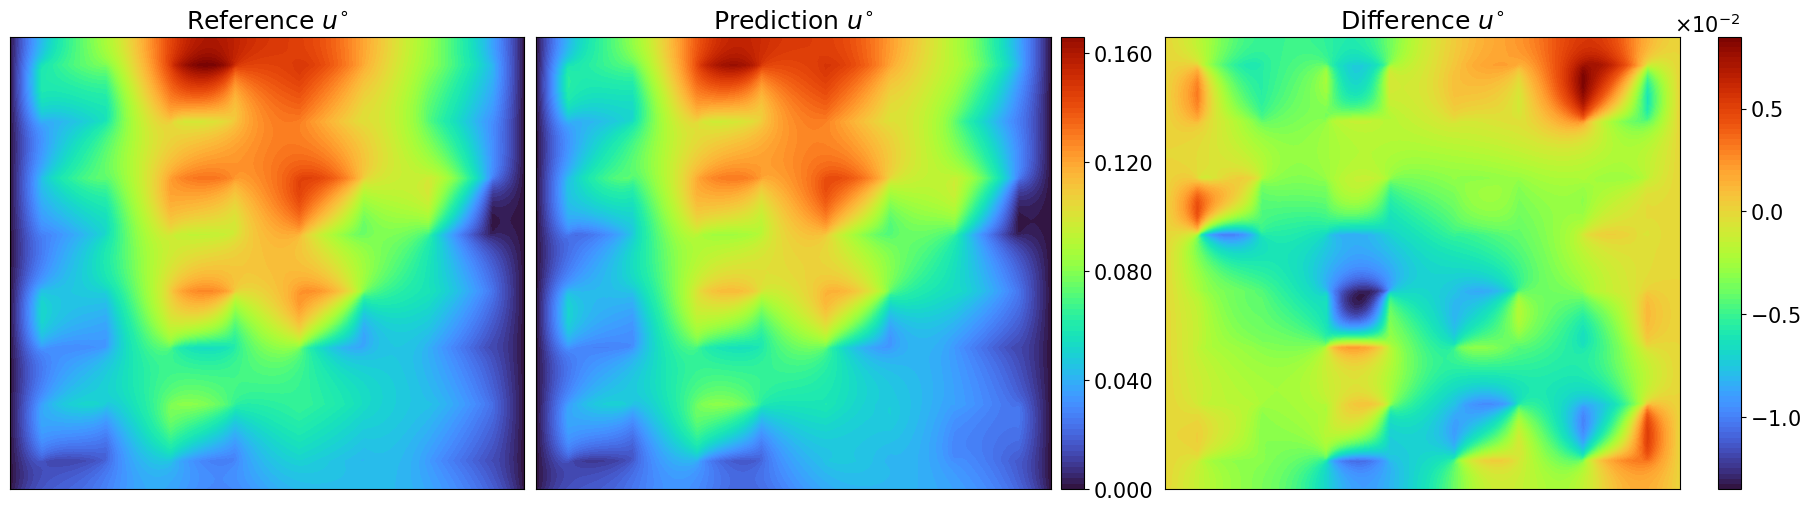

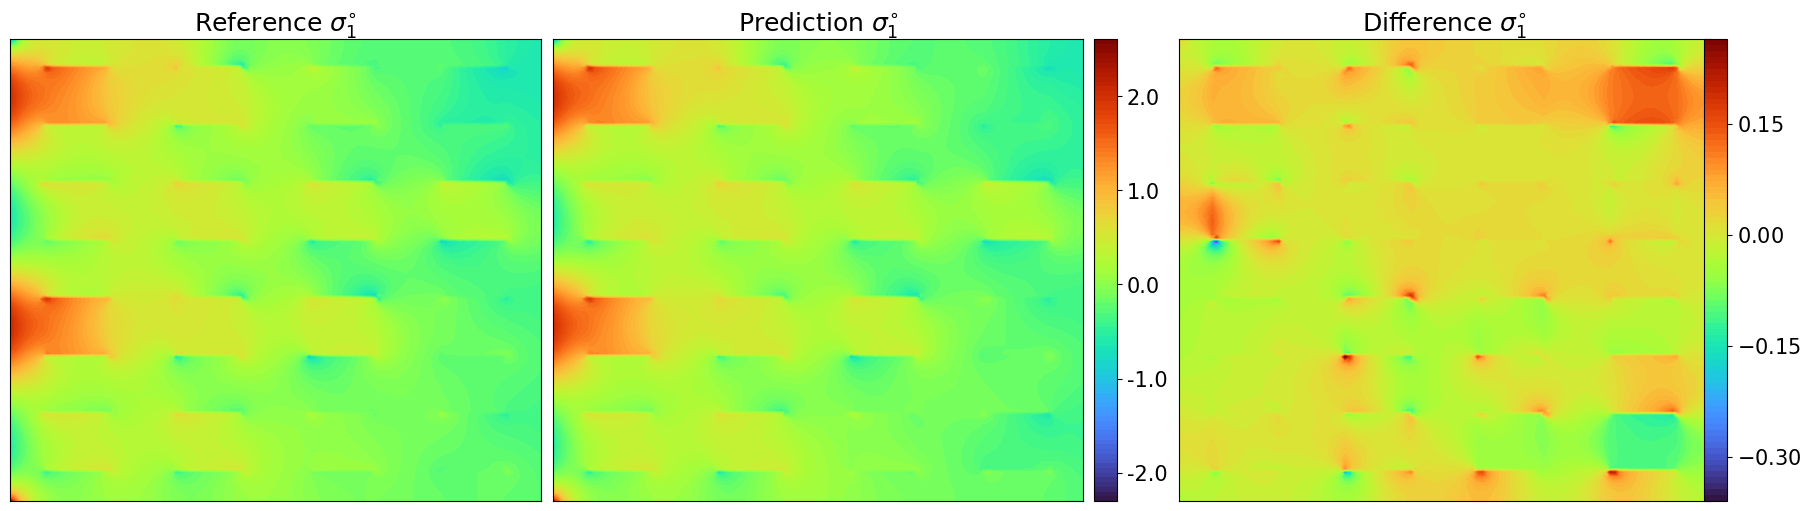

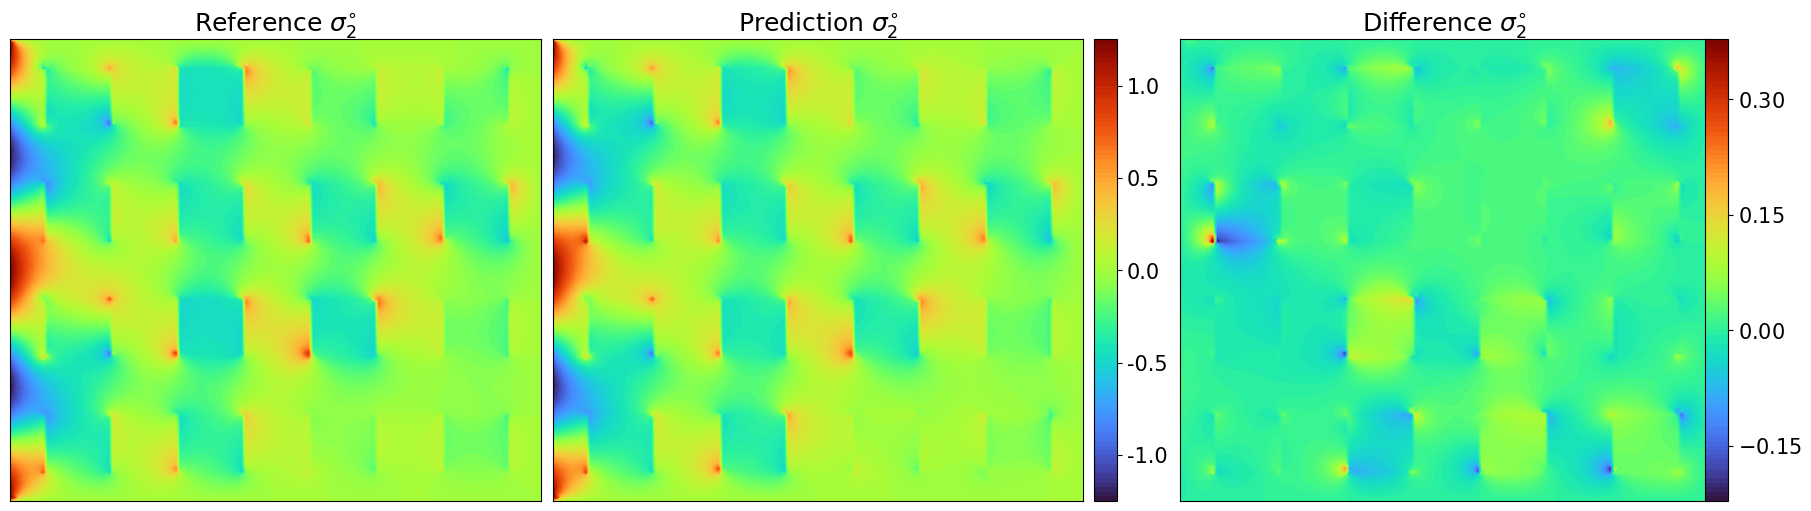

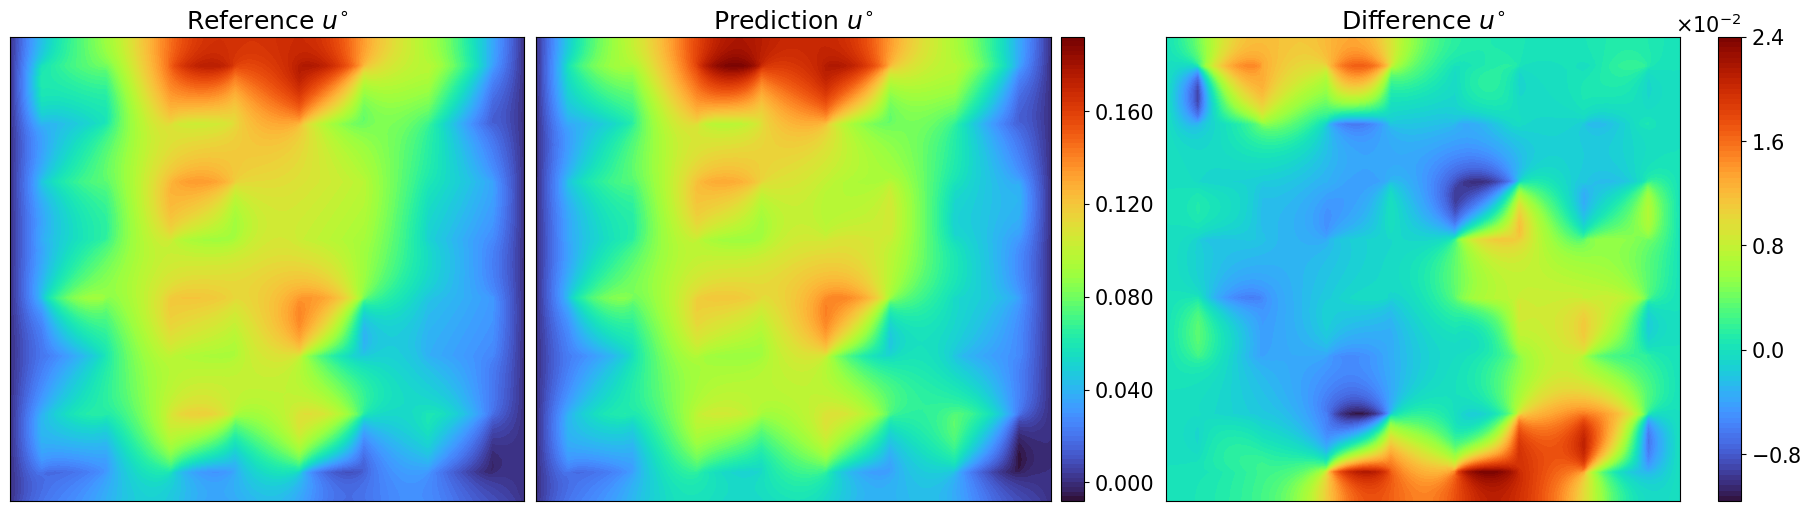

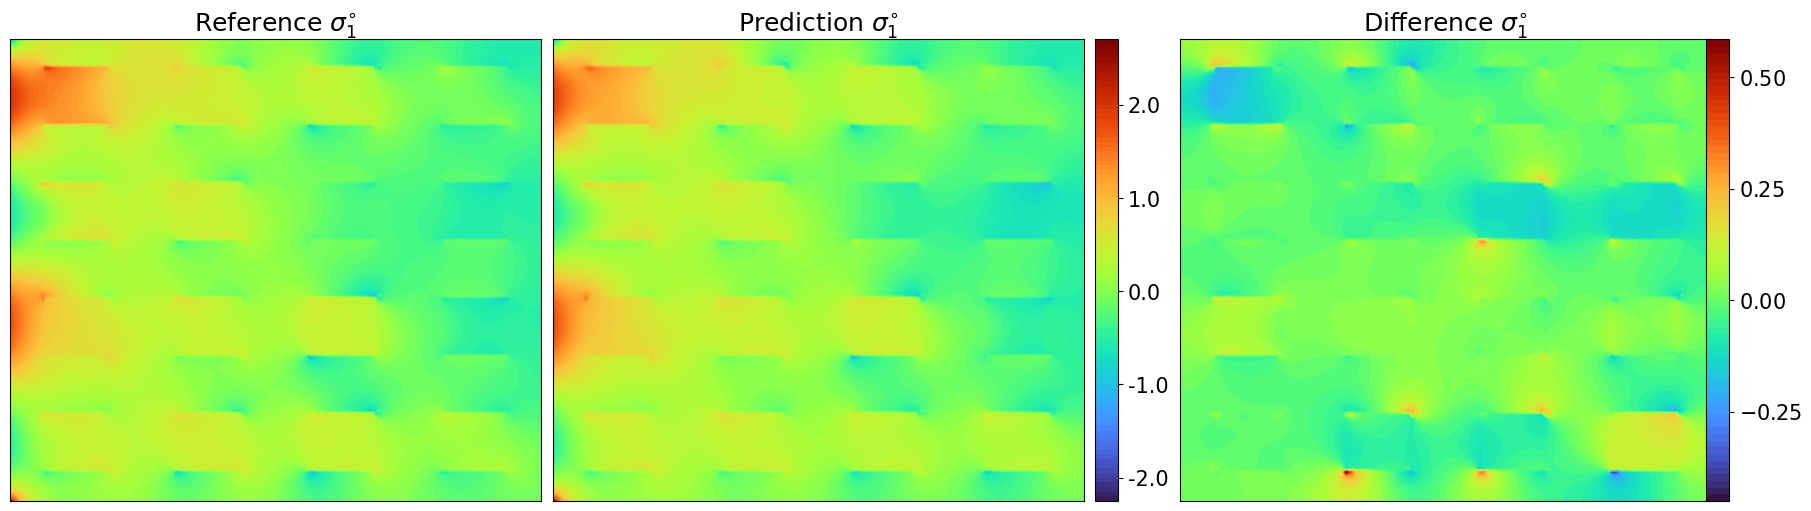

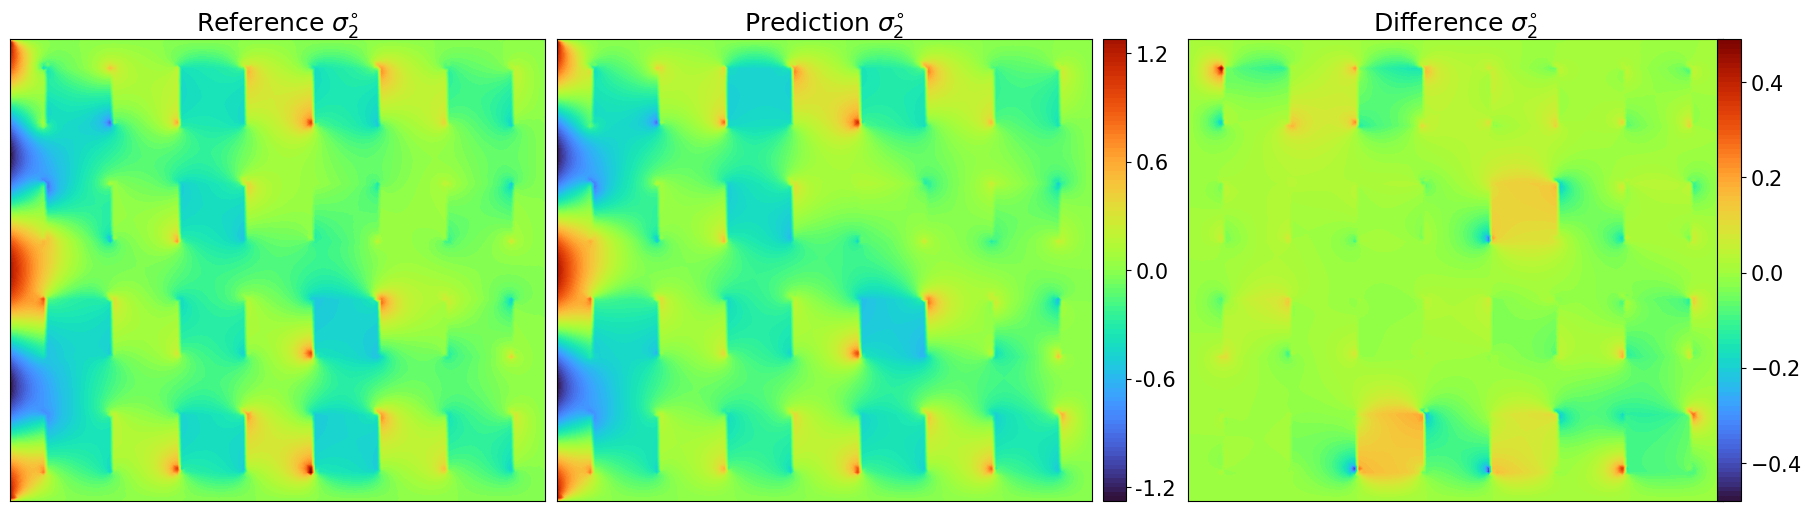

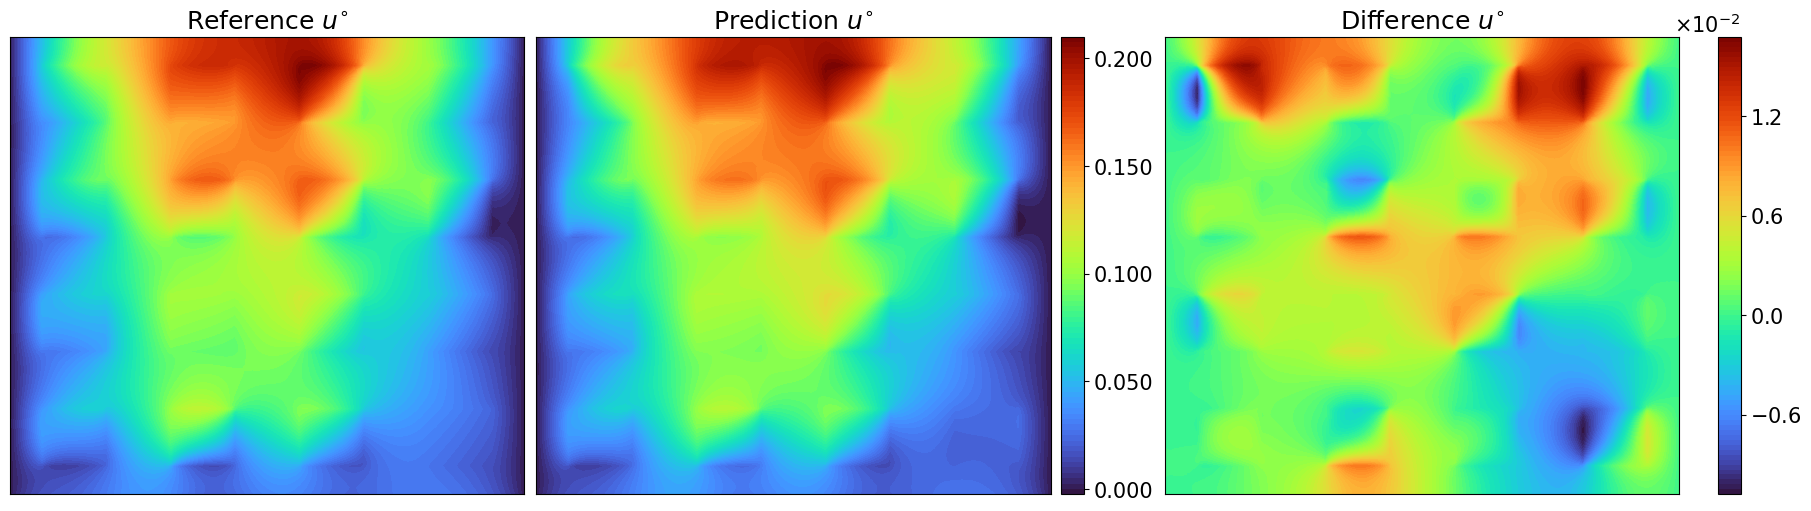

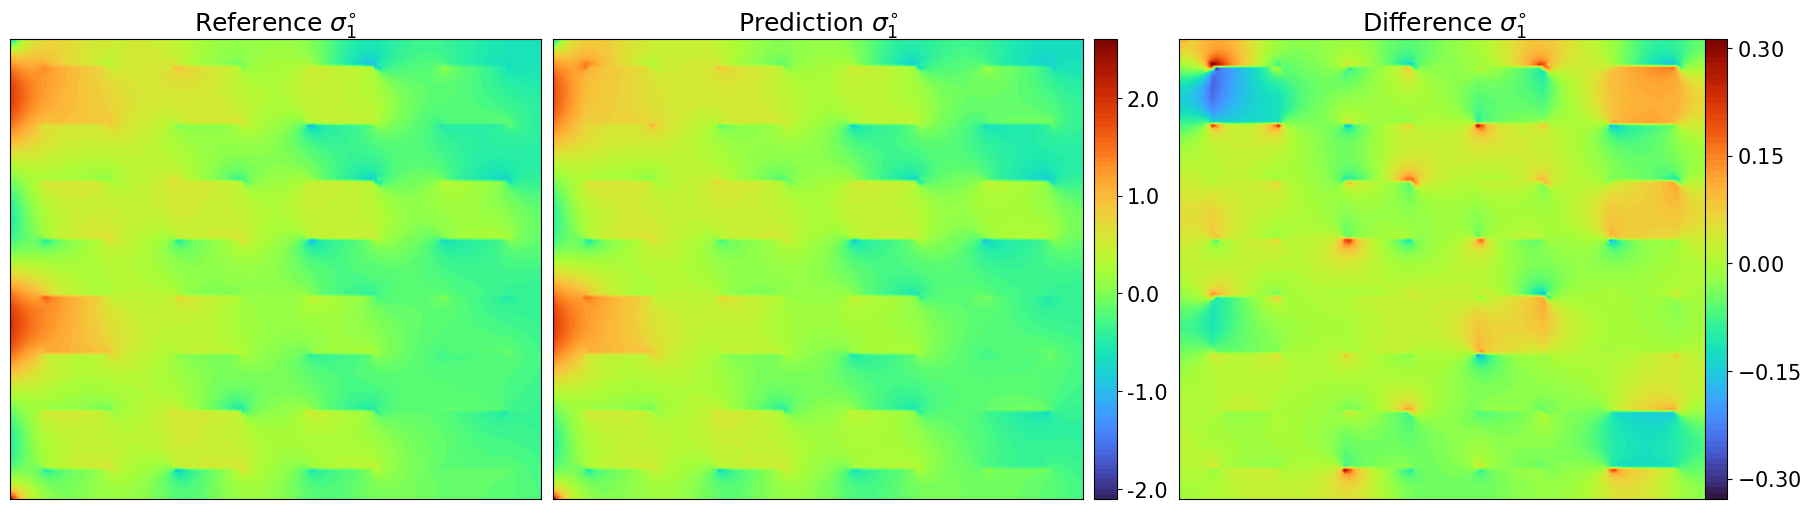

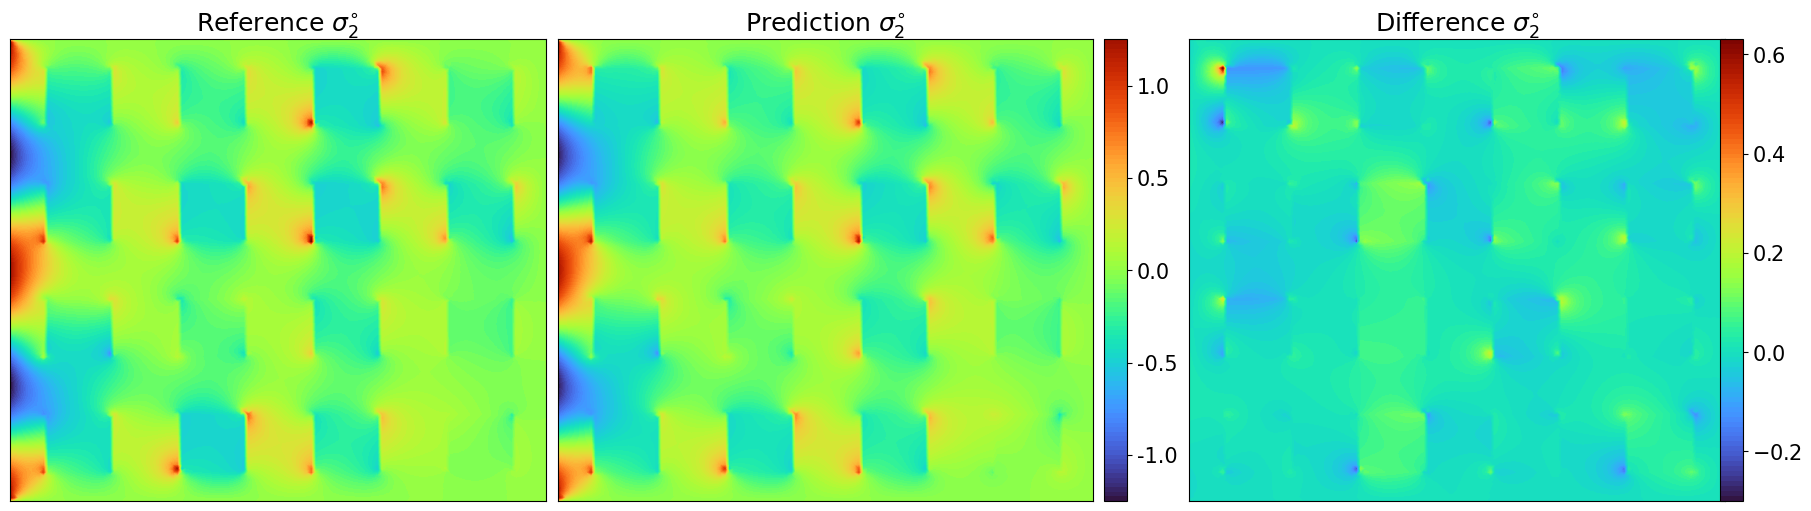

In [73]:
for test_sample_index in range(3):
    pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_sigma_u_fc.x.array[:] = test_pred[test_sample_index]
    pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
    pred_u_fc = pred_sigma_u_fc.sub(1).collapse()

    ref_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    ref_sigma_u_fc.x.array[:] = test_sigma_u_dof[test_sample_index]
    ref_sigma_fc = ref_sigma_u_fc.sub(0).collapse()
    ref_u_fc = ref_sigma_u_fc.sub(1).collapse()


    pred_sigma_grid_evals = evaluate_expression(mesh, pred_sigma_fc, mesh.geometry.x)[1]
    pred_u_grid_evals = evaluate_expression(mesh, pred_u_fc, mesh.geometry.x)[1]


    ref_sigma_grid_evals = evaluate_expression(mesh, ref_sigma_fc, mesh.geometry.x)[1]
    ref_u_grid_evals = evaluate_expression(mesh, ref_u_fc, mesh.geometry.x)[1]


    diff_sigma_grid_evals = pred_sigma_grid_evals - ref_sigma_grid_evals
    diff_u_grid_evals = pred_u_grid_evals - ref_u_grid_evals

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]


    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,0], pred_u_grid_evals[:,0], diff_u_grid_evals[:,0], r'$u^{\circ}$',
                            levels=100,
                            ref_pred_format='%.3f',
                            ref_pred_colorbar_pad=0.01,
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'u_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,0], pred_sigma_grid_evals[:, 0], diff_sigma_grid_evals[:, 0], r'$\sigma_1^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.01, 
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'sigma_1_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,1], pred_sigma_grid_evals[:, 1], diff_sigma_grid_evals[:, 1], r'$\sigma_2^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.01, 
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'sigma_2_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

In [74]:
compute_physical_loss_1 = poisson_least_squares.compute_physical_loss_1
compute_physical_loss_2 = poisson_least_squares.compute_physical_loss_2

In [75]:
residual_loss_dict = {
    'loss_1': np.zeros(num_test),
    'loss_2': np.zeros(num_test),
    'total_loss': np.zeros(num_test),
    'sqrt_total_loss': np.zeros(num_test)
}
for test_index in range(num_test): 
    pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_fc.x.array[:] = test_pred[test_index]
    pred_sigma_fc = pred_fc.sub(0).collapse()
    pred_u_fc = pred_fc.sub(1).collapse()

    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = test_p_dof[test_index]

    residual_loss_1 = compute_physical_loss_1(pred_sigma_fc, pred_u_fc, p_fc)
    residual_loss_2 = compute_physical_loss_2(pred_sigma_fc, pred_u_fc, p_fc)

    residual_loss = residual_loss_1 + residual_loss_2

    sqrt_residual_loss = np.sqrt(residual_loss)

    residual_loss_dict['loss_1'][test_index] = residual_loss_1
    residual_loss_dict['loss_2'][test_index] = residual_loss_2
    residual_loss_dict['total_loss'][test_index] = residual_loss
    residual_loss_dict['sqrt_total_loss'][test_index] = sqrt_residual_loss
    print(f'Test sample {test_index}:')
    print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2}')
    print(f'Total residual loss: {residual_loss} | Sqrt residual loss: {sqrt_residual_loss}')

    print("")

Test sample 0:
Residual loss 1: 0.02523194651249783 | Residual loss 2: 15.51863013307717
Total residual loss: 15.543862079589669 | Sqrt residual loss: 3.9425704913913293

Test sample 1:
Residual loss 1: 0.1378518736355764 | Residual loss 2: 19.941450490155802
Total residual loss: 20.079302363791378 | Sqrt residual loss: 4.480993457235948

Test sample 2:
Residual loss 1: 0.029189197630226427 | Residual loss 2: 18.576323294567555
Total residual loss: 18.605512492197782 | Sqrt residual loss: 4.313410772485943

Test sample 3:
Residual loss 1: 0.02270515860908073 | Residual loss 2: 24.617306733456545
Total residual loss: 24.640011892065626 | Sqrt residual loss: 4.963870656258645

Test sample 4:
Residual loss 1: 0.03124060971868649 | Residual loss 2: 17.45807019833909
Total residual loss: 17.489310808057777 | Sqrt residual loss: 4.18202233471532

Test sample 5:
Residual loss 1: 0.1868923416097142 | Residual loss 2: 21.36303558490391
Total residual loss: 21.54992792651362 | Sqrt residual loss

Test sample 80:
Residual loss 1: 0.04992951100469397 | Residual loss 2: 19.249036652693636
Total residual loss: 19.29896616369833 | Sqrt residual loss: 4.393058861852221

Test sample 81:
Residual loss 1: 0.0308726846407289 | Residual loss 2: 21.31067127033367
Total residual loss: 21.3415439549744 | Sqrt residual loss: 4.619690893877468

Test sample 82:
Residual loss 1: 0.02327104870964667 | Residual loss 2: 16.298113477345353
Total residual loss: 16.321384526055 | Sqrt residual loss: 4.039973332344534

Test sample 83:
Residual loss 1: 0.0808333297191089 | Residual loss 2: 17.1661682294242
Total residual loss: 17.24700155914331 | Sqrt residual loss: 4.152950945911029

Test sample 84:
Residual loss 1: 0.013125060105333916 | Residual loss 2: 15.991871346530449
Total residual loss: 16.004996406635783 | Sqrt residual loss: 4.000624502079117

Test sample 85:
Residual loss 1: 0.03899969694965474 | Residual loss 2: 25.027063975554825
Total residual loss: 25.06606367250448 | Sqrt residual loss:

In [76]:
np.save(os.path.join(model_test_outputs_path, "residual_loss_dict.npy"), residual_loss_dict)

In [77]:
print(f'mean residual loss 1: {np.mean(residual_loss_dict["loss_1"]):.2e} (std: {np.std(residual_loss_dict["loss_1"]):.2e})')
print(f'mean residual loss 2: {np.mean(residual_loss_dict["loss_2"]):.2e} (std: {np.std(residual_loss_dict["loss_2"]):.2e})')
print(f'mean total residual loss: {np.mean(residual_loss_dict["total_loss"]):.2e} (std: {np.std(residual_loss_dict["total_loss"]):.2e})')
print(f'mean sqrt total residual loss: {np.mean(residual_loss_dict["sqrt_total_loss"]):.2e} (std: {np.std(residual_loss_dict["sqrt_total_loss"]):.2e})')

mean residual loss 1: 4.52e-02 (std: 3.49e-02)
mean residual loss 2: 1.83e+01 (std: 3.01e+00)
mean total residual loss: 1.84e+01 (std: 3.01e+00)
mean sqrt total residual loss: 4.27e+00 (std: 3.52e-01)


In [78]:
ratio_list = []
for test_index in range(num_test):
    ratio = np.sqrt(sigma_u_error_dict['squared_hdiv_h1'])[test_index] / residual_loss_dict['sqrt_total_loss'][test_index]
    ratio_list.append(ratio)
    print(f'index: {test_index} | ratio: {ratio}')

index: 0 | ratio: 0.9995978372079607
index: 1 | ratio: 0.9971308442474013
index: 2 | ratio: 0.9997092735551568
index: 3 | ratio: 1.0000783976792305
index: 4 | ratio: 0.9995209440354619
index: 5 | ratio: 0.9962342373336028
index: 6 | ratio: 1.0001042104442492
index: 7 | ratio: 0.9999855702004273
index: 8 | ratio: 0.9995657928365368
index: 9 | ratio: 0.9994712703616511
index: 10 | ratio: 0.9995036947614897
index: 11 | ratio: 0.9989584376399294
index: 12 | ratio: 0.9998807986701455
index: 13 | ratio: 0.999347171668214
index: 14 | ratio: 0.9964594520917357
index: 15 | ratio: 0.9993390500921455
index: 16 | ratio: 0.9989124640670555
index: 17 | ratio: 0.9999891100357751
index: 18 | ratio: 0.9996345040607489
index: 19 | ratio: 0.9988583025260558
index: 20 | ratio: 0.9999463782338451
index: 21 | ratio: 0.9998112119956529
index: 22 | ratio: 0.9991264208882223
index: 23 | ratio: 0.9998451953011577
index: 24 | ratio: 0.9990797529042525
index: 25 | ratio: 0.9994561086959738
index: 26 | ratio: 0.99

In [79]:
plt.figure(figsize=(10, 8))  # Optional: bigger figure
plt.hist(ratio_list, bins=10)

plt.xlabel('Value', fontsize=25) 
plt.ylabel('Frequency', fontsize=25)
plt.title(fr'Error / $\sqrt{{\text{{Loss}}}}$ (# test = {num_test})', fontsize=25)

plt.xticks(fontsize=23)
plt.yticks(fontsize=23)

plt.savefig(os.path.join(model_test_outputs_path, 'ratio_histogram_hdiv_h1.png'),
            dpi=300, bbox_inches='tight')
plt.close()

In [80]:
cg1_residual_loss_dict = {
    'loss_1': np.zeros(num_test),
    'loss_2': np.zeros(num_test),
    'total_loss': np.zeros(num_test),
    'sqrt_total_loss': np.zeros(num_test)
}
for test_index in range(num_test): 
    # pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    # pred_fc.x.array[:] = test_pred[test_index]
    # pred_sigma_fc = pred_fc.sub(0).collapse()
    # pred_u_fc = pred_fc.sub(1).collapse()

    test_CG1_sigma_pred_fc = test_CG1_sigma_fc_pred_list[test_index]
    test_CG1_u_pred_fc = test_CG1_u_fc_pred_list[test_index]

    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = test_p_dof[test_index]

    residual_loss_1 = compute_physical_loss_1(test_CG1_sigma_pred_fc, test_CG1_u_pred_fc, p_fc)
    residual_loss_2 = compute_physical_loss_2(test_CG1_sigma_pred_fc, test_CG1_u_pred_fc, p_fc)

    residual_loss = residual_loss_1 + residual_loss_2

    sqrt_residual_loss = np.sqrt(residual_loss)

    cg1_residual_loss_dict['loss_1'][test_index] = residual_loss_1
    cg1_residual_loss_dict['loss_2'][test_index] = residual_loss_2
    cg1_residual_loss_dict['total_loss'][test_index] = residual_loss
    cg1_residual_loss_dict['sqrt_total_loss'][test_index] = sqrt_residual_loss
    print(f'Test sample {test_index}:')
    print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2}')
    print(f'Total residual loss: {residual_loss} | Sqrt residual loss: {sqrt_residual_loss}')

    print("")
    

Test sample 0:
Residual loss 1: 0.02523106783256684 | Residual loss 2: 15.51863033883576
Total residual loss: 15.543861406668325 | Sqrt residual loss: 3.942570406050896

Test sample 1:
Residual loss 1: 0.13785321101413703 | Residual loss 2: 19.94145103565441
Total residual loss: 20.079304246668546 | Sqrt residual loss: 4.480993667331895

Test sample 2:
Residual loss 1: 0.029189757367029008 | Residual loss 2: 18.576323833668418
Total residual loss: 18.605513591035447 | Sqrt residual loss: 4.313410899860509

Test sample 3:
Residual loss 1: 0.022704584338838124 | Residual loss 2: 24.6173074222952
Total residual loss: 24.64001200663404 | Sqrt residual loss: 4.963870667798874

Test sample 4:
Residual loss 1: 0.031240725562241518 | Residual loss 2: 17.458070277421868
Total residual loss: 17.48931100298411 | Sqrt residual loss: 4.182022358020592

Test sample 5:
Residual loss 1: 0.18689451709674082 | Residual loss 2: 21.363036210286683
Total residual loss: 21.549930727383423 | Sqrt residual lo

Test sample 11:
Residual loss 1: 0.0512677885217049 | Residual loss 2: 16.949694202027242
Total residual loss: 17.000961990548948 | Sqrt residual loss: 4.123222282456883

Test sample 12:
Residual loss 1: 0.017136359769106203 | Residual loss 2: 18.053828527959347
Total residual loss: 18.070964887728454 | Sqrt residual loss: 4.250995752494756

Test sample 13:
Residual loss 1: 0.03439218659880661 | Residual loss 2: 15.981015220555516
Total residual loss: 16.015407407154324 | Sqrt residual loss: 4.001925462468575

Test sample 14:
Residual loss 1: 0.16083473424008635 | Residual loss 2: 18.66904042660443
Total residual loss: 18.829875160844516 | Sqrt residual loss: 4.339340406195913

Test sample 15:
Residual loss 1: 0.04168970202484673 | Residual loss 2: 18.444392309586448
Total residual loss: 18.486082011611295 | Sqrt residual loss: 4.299544395818154

Test sample 16:
Residual loss 1: 0.06600989246086093 | Residual loss 2: 20.313558919577854
Total residual loss: 20.379568812038716 | Sqrt res

In [81]:
print(f'mean CG1 residual loss 1: {np.mean(cg1_residual_loss_dict["loss_1"]):.2e} (std: {np.std(cg1_residual_loss_dict["loss_1"]):.2e})')
print(f'mean CG1 residual loss 2: {np.mean(cg1_residual_loss_dict["loss_2"]):.2e} (std: {np.std(cg1_residual_loss_dict["loss_2"]):.2e})')
print(f'mean CG1 total residual loss: {np.mean(cg1_residual_loss_dict["total_loss"]):.2e} (std: {np.std(cg1_residual_loss_dict["total_loss"]):.2e})')
print(f'mean sqrt CG1 total residual loss: {np.mean(cg1_residual_loss_dict["sqrt_total_loss"]):.2e} (std: {np.std(cg1_residual_loss_dict["sqrt_total_loss"]):.2e})')

mean CG1 residual loss 1: 4.52e-02 (std: 3.49e-02)
mean CG1 residual loss 2: 1.83e+01 (std: 3.01e+00)
mean CG1 total residual loss: 1.84e+01 (std: 3.01e+00)
mean sqrt CG1 total residual loss: 4.27e+00 (std: 3.52e-01)
